In [1]:
%matplotlib inline
#
from multifunbrain import *
from multifunbrain.notebook import *
#
if Path.cwd().name != 'multifun-brain':
    path_root = Path.cwd().parent
    os.chdir(path_root)
#
path_data =  path_root / 'data'
path_fig = path_data / 'figures'
path_ts = path_data / 'atlas_timecourses'
path_corrmat = path_data / 'correlation_matrices'
path_imf_matrices = path_corrmat / 'bold_matrices_from_IMF'
#

### Set the atlas

In [2]:
# Fetch the Harvard-Oxford cortical atlas.
atlas = datasets.fetch_atlas_harvard_oxford(
    'cort-maxprob-thr50-2mm', data_dir=path_data
)
atlas_filename = atlas.maps
atlas_img = image.load_img(atlas_filename)
atlas_data = atlas_img.get_fdata()
#
rois = atlas.labels
rois_label_map = {i: ll for i,ll in enumerate(rois[1:])}
roi_indices = np.unique(list(rois_label_map.keys()))
# Load MNI152 template for the background.
template = load_mni152_template()

[get_dataset_dir] Dataset found in /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/fsl


### Plotting the IMF

In [3]:
# Path to time series folders
pn_timeseries = list(path_ts.iterdir())
# Shared filenames 
fn_timeseries = [pn.name for pn in pn_timeseries[0].iterdir()]

In [4]:
signal = 1
# Load the time series data.
ts = np.loadtxt(pn_timeseries[0] / fn_timeseries[signal]).T
# Remove zero signals
zeros = np.where(np.sum(ts, axis=1) == 0)[0].astype(int)
ts = np.delete(ts, zeros, axis=0)
# Get the filename without the prefix and suffix
fname = (fn_timeseries[signal]
         .replace('HarvardOxford_48Parcels_', '')
         .replace('.ts.1D', ''))
print(fname, ts.shape)

kwfcurN_Vaso (48, 444)


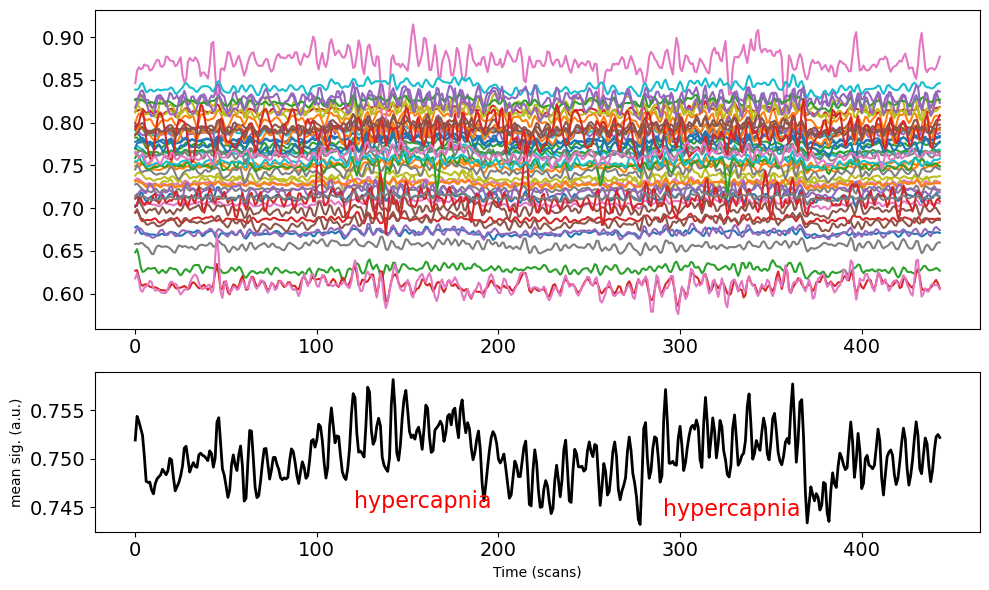

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), height_ratios=[1,0.5])
#
plt.rcParams['axes.labelsize'] = 16  # For axis labels
#
for i in range(ts.shape[0]):
    ax[0].plot(ts[i, :])
ax[1].plot(np.mean(ts, axis=0), color='k', lw=2)
#
ax[1].set_xlabel('Time (scans)')
ax[1].set_ylabel(fname + ' (a.u.)')
#
ax[1].set_ylabel('mean sig. (a.u.)')
for xvalues in [(0.37,0.15), (0.72, 0.1)]:
    ax[1].annotate('hypercapnia', xy=xvalues, xycoords='axes fraction', fontsize=16, ha='center', color='r')
#
for axx in ax:
    axx.tick_params(axis='both', which='major', labelsize=14)
#
fig.tight_layout()
fig.savefig(path_fig / '_'.join([fname,'timecourses.pdf']), bbox_inches='tight',transparent=True)

### EMD Analysis and Frequency Histogram

Following the EMD methodology to extract intrinsic mode functions (IMFs) and analyze their characteristic frequencies across different frequency bands (slow-5, slow-4, and s*).

In [6]:
# EMD decomposition for all ROI timecourses
sampling_rate = 1.0  # Assuming 1 Hz sampling rate (adjust if different)

# Store all characteristic frequencies across all ROIs
all_char_frequencies = []
all_imfs_data = []

print(f"Performing EMD decomposition on {ts.shape[0]} ROI timecourses...")

for roi_idx in range(ts.shape[0]):
    # Extract IMFs for this ROI
    imfs = emd.sift.mask_sift(ts[roi_idx, :], max_imfs=6)
    all_imfs_data.append(imfs)
    
    # Calculate instantaneous frequency for each IMF using Hilbert transform
    for imf_idx in range(imfs.shape[0] - 1):  # Exclude residual (last component)
        # Get the IMF
        imf = imfs[imf_idx, :]
        
        # Skip IMFs with very low variance (likely residual-like components)
        if np.var(imf) < 1e-10:
            continue
            
        # Calculate instantaneous frequency via Hilbert transform
        IP, IF, IA = emd.spectra.frequency_transform(imf, sampling_rate, 'hilbert')
        
        # Calculate characteristic frequency (mean instantaneous frequency)
        # Remove NaN values, negative frequencies, and outliers for robust estimation
        valid_freq = IF[~np.isnan(IF)]
        if len(valid_freq) > 0:
            # Remove negative frequencies and extreme outliers (frequencies > Nyquist frequency)
            valid_freq = valid_freq[(valid_freq > 0) & (valid_freq < sampling_rate/2)]
            if len(valid_freq) > 0:
                # Use median instead of mean for more robust estimation
                char_freq = np.median(valid_freq)
                # Only include frequencies that are reasonable for fMRI data (> 0.001 Hz)
                if char_freq > 0.001:
                    all_char_frequencies.append(char_freq)

all_char_frequencies = np.array(all_char_frequencies)
print(f"Extracted {len(all_char_frequencies)} characteristic frequencies from IMFs")
print(f"Frequency range: {all_char_frequencies.min():.4f} - {all_char_frequencies.max():.4f} Hz")

Performing EMD decomposition on 48 ROI timecourses...
Extracted 19818 characteristic frequencies from IMFs
Frequency range: 0.0010 - 0.4618 Hz
Extracted 19818 characteristic frequencies from IMFs
Frequency range: 0.0010 - 0.4618 Hz



Frequency band statistics:
slow-5 (0.01-0.027 Hz): 1427 IMFs (7.2%)
slow-4 (0.027-0.073 Hz): 4387 IMFs (22.1%)
s* (0.073-0.18 Hz): 10148 IMFs (51.2%)
Total IMFs analyzed: 19818


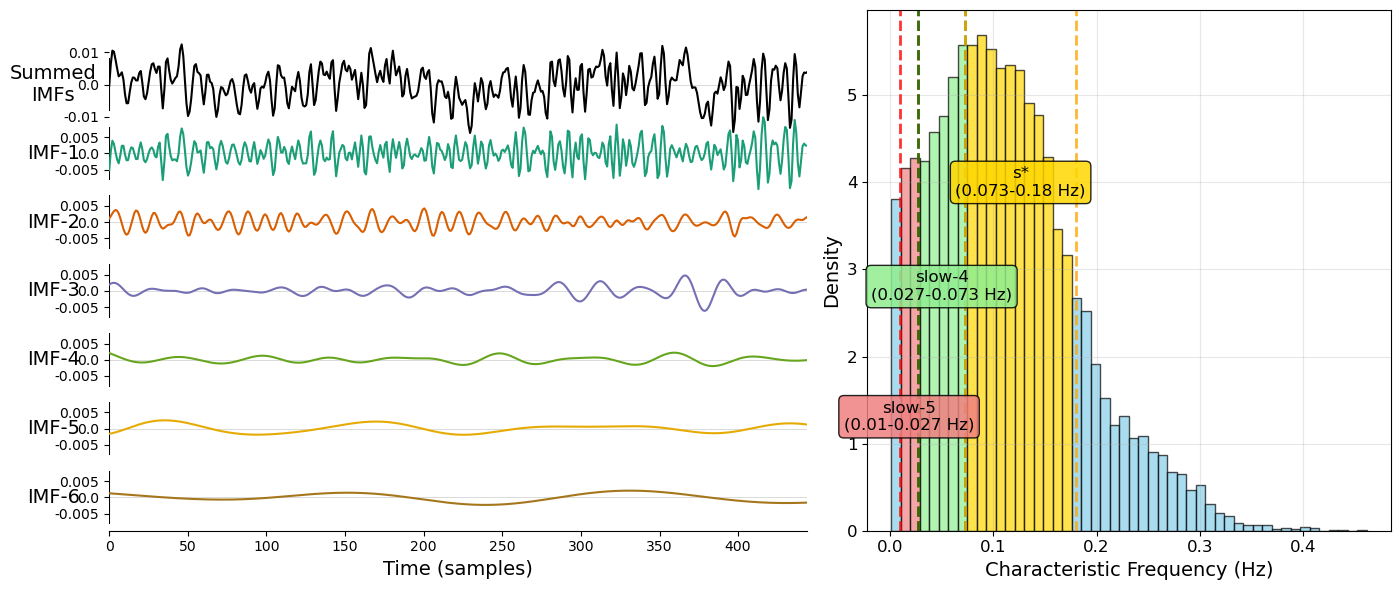

In [7]:
# Define frequency bands as described in the paper
slow5_band = (0.01, 0.027)      # slow-5 band
slow4_band = (0.027, 0.073)     # slow-4 band  
s_star_band = (0.073, 0.18)     # s* band (additional cluster found in IMF analysis)

# Create histogram of characteristic frequencies
fig, ax = plt.subplots(1, 2, figsize=(14, 6), width_ratios=[2,1.5])


imf = emd.sift.mask_sift(ts[1, :], max_imfs=6)
emd.plotting.plot_imfs(imf, ax=ax[0])


# Main histogram
n_bins = 50
counts, bins, patches = ax[1].hist(all_char_frequencies, bins=n_bins, alpha=0.7, 
                                color='skyblue', edgecolor='black', density=True)

# Color-code the frequency bands
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if slow5_band[0] <= bin_center <= slow5_band[1]:
        patch.set_facecolor('lightcoral')
        patch.set_label('slow-5' if i == 0 else "")
    elif slow4_band[0] <= bin_center <= slow4_band[1]:
        patch.set_facecolor('lightgreen')
        patch.set_label('slow-4' if i == 0 else "")
    elif s_star_band[0] <= bin_center <= s_star_band[1]:
        patch.set_facecolor('gold')
        patch.set_label('s*' if i == 0 else "")

# Add vertical lines for band boundaries
ax[1].axvline(slow5_band[0], color='red', linestyle='--', alpha=0.8, linewidth=2)
ax[1].axvline(slow5_band[1], color='red', linestyle='--', alpha=0.8, linewidth=2)
ax[1].axvline(slow4_band[0], color='green', linestyle='--', alpha=0.8, linewidth=2)
ax[1].axvline(slow4_band[1], color='green', linestyle='--', alpha=0.8, linewidth=2)
ax[1].axvline(s_star_band[0], color='orange', linestyle='--', alpha=0.8, linewidth=2)
ax[1].axvline(s_star_band[1], color='orange', linestyle='--', alpha=0.8, linewidth=2)

# Add band labels
ax[1].text(np.mean(slow5_band), ax[1].get_ylim()[1]*0.25, 'slow-5\n(0.01-0.027 Hz)', 
        ha='center', va='top', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.85))
ax[1].text(np.mean(slow4_band), ax[1].get_ylim()[1]*0.5, 'slow-4\n(0.027-0.073 Hz)', 
        ha='center', va='top', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.85))
ax[1].text(np.mean(s_star_band), ax[1].get_ylim()[1]*0.7, 's*\n(0.073-0.18 Hz)', 
        ha='center', va='top', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.85))

ax[1].set_xlabel('Characteristic Frequency (Hz)', fontsize=14)
ax[1].set_ylabel('Density', fontsize=14)
# ax[1].set_title(f'Histogram of IMF Characteristic Frequencies\n({fname} signal, {ts.shape[0]} ROIs)', fontsize=16)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis='both', which='major', labelsize=12)

fig.tight_layout()
fig.savefig(path_fig / '_'.join([fname,'IMFs.pdf']), bbox_inches='tight',transparent=True)


# Print statistics for each band
print(f"\nFrequency band statistics:")
print(f"slow-5 ({slow5_band[0]}-{slow5_band[1]} Hz): {np.sum((all_char_frequencies >= slow5_band[0]) & (all_char_frequencies <= slow5_band[1]))} IMFs ({np.mean((all_char_frequencies >= slow5_band[0]) & (all_char_frequencies <= slow5_band[1]))*100:.1f}%)")
print(f"slow-4 ({slow4_band[0]}-{slow4_band[1]} Hz): {np.sum((all_char_frequencies >= slow4_band[0]) & (all_char_frequencies <= slow4_band[1]))} IMFs ({np.mean((all_char_frequencies >= slow4_band[0]) & (all_char_frequencies <= slow4_band[1]))*100:.1f}%)")
print(f"s* ({s_star_band[0]}-{s_star_band[1]} Hz): {np.sum((all_char_frequencies >= s_star_band[0]) & (all_char_frequencies <= s_star_band[1]))} IMFs ({np.mean((all_char_frequencies >= s_star_band[0]) & (all_char_frequencies <= s_star_band[1]))*100:.1f}%)")
print(f"Total IMFs analyzed: {len(all_char_frequencies)}")

In [8]:
signal = 3
# Load the time series data.
ts = np.loadtxt(pn_timeseries[0] / fn_timeseries[signal]).T
# Remove zero signals
zeros = np.where(np.sum(ts, axis=1) == 0)[0].astype(int)
ts = np.delete(ts, zeros, axis=0)
# Get the filename without the prefix and suffix
fname = (fn_timeseries[signal]
         .replace('HarvardOxford_48Parcels_', '')
         .replace('.ts.1D', ''))
print(fname, ts.shape)

kwfurN_Bold (48, 444)


In [9]:
# Save the frequency histogram figure
fig.savefig(path_fig / f'{fname}_IMF_frequency_histogram.pdf', bbox_inches='tight', transparent=True)
print(f"Saved histogram to: {path_fig / f'{fname}_IMF_frequency_histogram.pdf'}")

# Optional: Save the characteristic frequencies data for further analysis
freq_data = {
    'all_characteristic_frequencies': all_char_frequencies,
    'frequency_bands': {
        'slow5': slow5_band,
        'slow4': slow4_band,
        's_star': s_star_band
    },
    'signal_name': fname,
    'n_rois': ts.shape[0],
    'n_imfs_total': len(all_char_frequencies)
}

import pickle
with open(path_data / f'{fname}_IMF_frequencies.pkl', 'wb') as f:
    pickle.dump(freq_data, f)
print(f"Saved frequency data to: {path_data / f'{fname}_IMF_frequencies.pkl'}")

Saved histogram to: /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/figures/kwfurN_Bold_IMF_frequency_histogram.pdf
Saved frequency data to: /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/kwfurN_Bold_IMF_frequencies.pkl


### Load matrix

In [10]:
fnames = os.listdir(path_imf_matrices)
bold_matrix_test = {}
for fn in fnames:
    pn = path_imf_matrices / fn
    if not pn.is_file():
        fnames.remove(fn)
        continue
    with open(pn, 'rb') as f:
        bold_matrix_test[fn] = pk.load(f)

NameError: name 'imshow_colorbar_caxdivider' is not defined

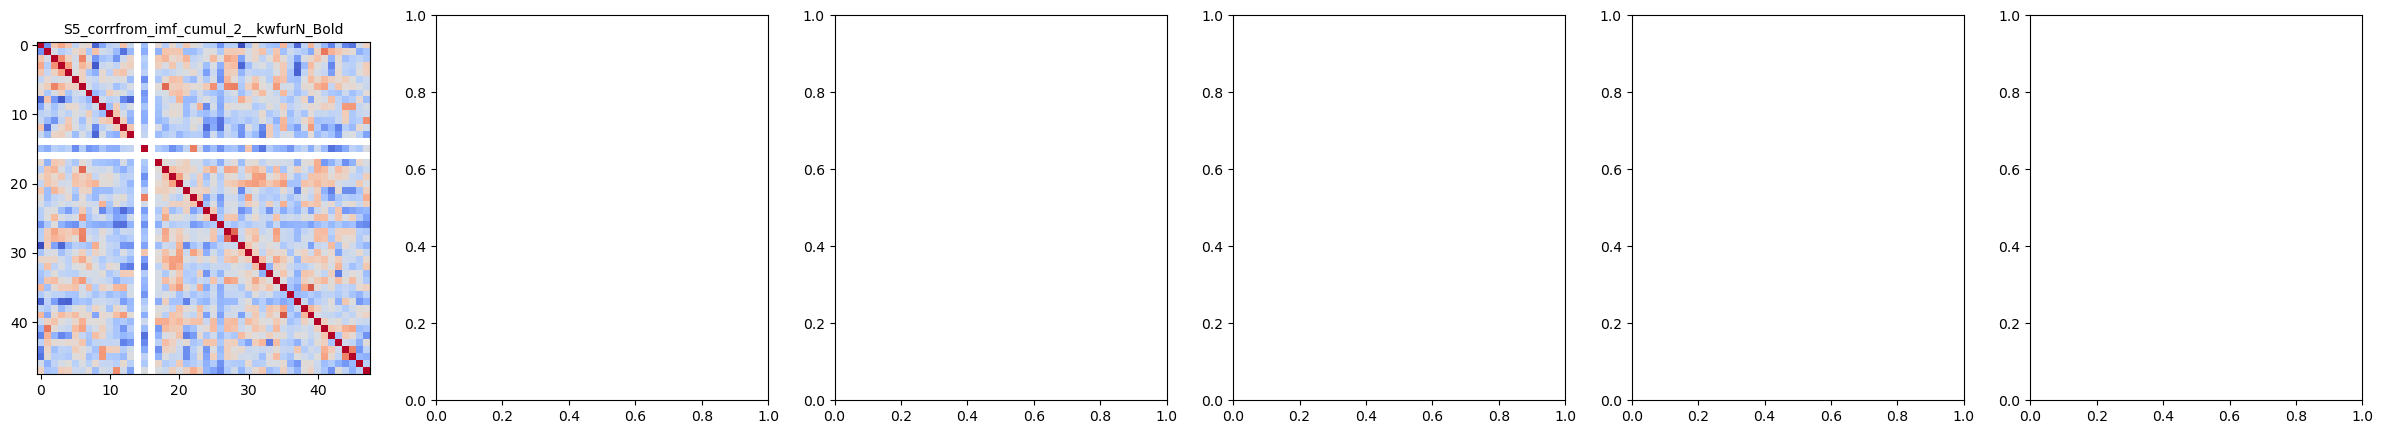

In [11]:
fig, ax = plt.subplots(1, len(fnames), figsize=(5*len(fnames), 5))
for i, fn in enumerate(fnames):
    im = ax[i].imshow(bold_matrix_test[fn], cmap='coolwarm')
    fnn = fn.replace('HarvardOxford_48Parcels', '').replace('.ts.1D.pkl', '')
    ax[i].set_title(fnn, fontsize=10)
    div, cax, clb = imshow_colorbar_caxdivider(im, ax[i])
fig.tight_layout()

In [ ]:
fn = fnames[3]
G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(bold_matrix_test[fn]))
G = nx.convert_node_labels_to_integers(G)
#
L, spectrum = graph_laplacian_and_spectrum(G)

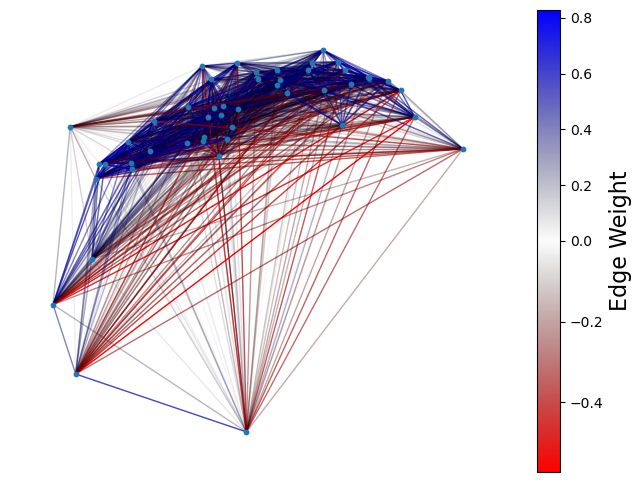

In [ ]:
edge_weights = [G[u][v].get('weight', 0) for u, v in G.edges()]
norm = TwoSlopeNorm(vmin=min(edge_weights), vcenter=0, vmax=max(edge_weights))
cmap = LinearSegmentedColormap.from_list(
    'red_transparent_blue',
    [(0.0, (1, 0, 0, 1)),      # Red, opaque
     (0.5, (0, 0, 0, .01)),      # Transparent (white, alpha=0)
     (1.0, (0, 0, 1, 1))],     # Blue, opaque
    N=256
)
edge_colors = [cmap(norm(w)) for w in edge_weights]
#
fig, ax = plt.subplots(figsize=(8,6))
#
nx.draw(G, ax=ax, edge_color=edge_colors, node_size=10)
#
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(edge_weights)
#
plt.colorbar(sm, ax=ax, label='Edge Weight')
plt.show()

In [ ]:
A_old = nx.to_numpy_array(G)
A_new = np.abs(A_old)#np.where(A_old < 0, 0, A_old)
G_pos = nx.from_numpy_array(A_new)
Th, Einf, Pinf = compute_threshold_stats_fast(G_pos)
Th, jump = find_threshold_jumps(G_pos)

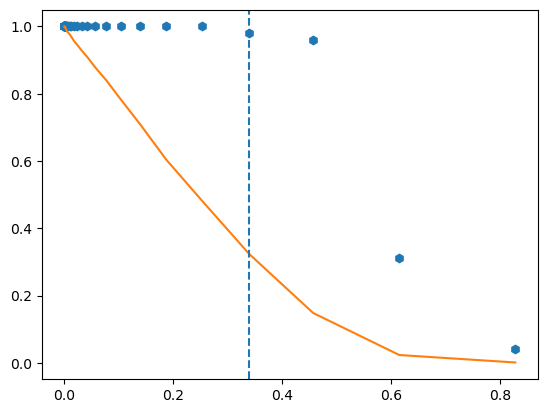

In [ ]:
sel_thresh = Th[jump[1]]
plt.plot(Th, Pinf, 'h')
plt.plot(Th, Einf)
plt.axvline(sel_thresh, ls='--')

In [ ]:
A_prime = nx.to_numpy_array(G_pos)
A_thresh = np.where(A_prime < sel_thresh, 0, A_prime)
G_pos, lost_nodes_1 = get_giant_component_leftoff(nx.from_numpy_array(A_thresh))

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:57: RuntimeWarning: divide by zero encountered in log
  """
/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:57: RuntimeWarning: invalid value encountered in multiply
  """


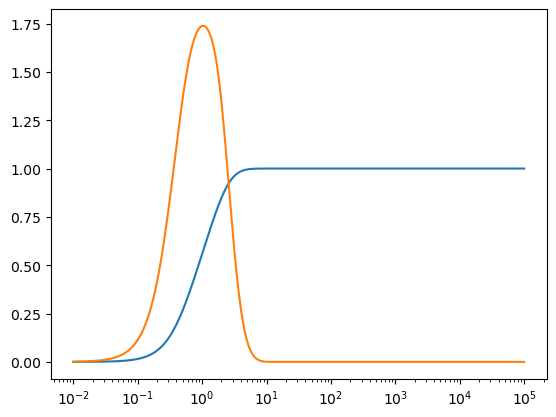

In [ ]:
L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
Sm1, dS, VarL, tau  = entropy(spectrum)
plt.plot(tau, Sm1)
plt.plot(tau[1:], dS)
plt.xscale('log')

In [ ]:
1/spectrum

array([8.04214359e+13, 8.12733148e-01, 5.55756975e-01, 5.35628316e-01,
       4.74632029e-01, 3.56875992e-01, 3.22675889e-01, 2.55717069e-01,
       2.49595013e-01, 2.29460329e-01, 2.19316224e-01, 2.07759144e-01,
       2.02281294e-01, 1.95357951e-01, 1.84196350e-01, 1.78213763e-01,
       1.70903989e-01, 1.68955604e-01, 1.62146780e-01, 1.54996389e-01,
       1.49359743e-01, 1.43932920e-01, 1.38891949e-01, 1.38173455e-01,
       1.36496115e-01, 1.27127289e-01, 1.25420808e-01, 1.20407200e-01,
       1.16114997e-01, 1.13679330e-01, 1.05489809e-01, 1.02125814e-01,
       1.00501668e-01, 9.83041867e-02, 9.60867948e-02, 9.43134232e-02,
       9.38979464e-02, 9.27668279e-02, 9.23431999e-02, 9.12213607e-02,
       9.00653969e-02, 8.77196619e-02, 8.42369186e-02, 8.35733858e-02,
       8.24451351e-02, 8.08203263e-02, 7.91046206e-02])

In [ ]:
tau = 1/max(spectrum)
rho_m = lambda tau: rho_matrix(tau, L)
dists = symmetrized_inverse_distance(tau, rho_m)
linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
tmin = linkage_matrix[::, 2][0] - 0.5*linkage_matrix[::, 2][0]
threshold, *_ = compute_optimal_threshold(linkage_matrix)
optimal_clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')

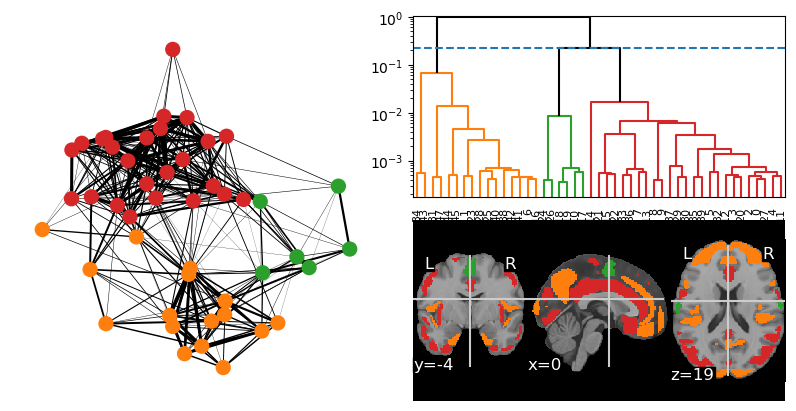

In [ ]:
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)

ax_dendro = fig.add_subplot(gs[0:2, 3:6])
dendro = dendrogram(
    linkage_matrix,
    ax=ax_dendro,
    color_threshold=threshold,
    above_threshold_color='k',
    orientation='top',
    labels=label_list
)
ax_dendro.set_yscale('log')
ax_dendro.axhline(threshold, ls='--')
ax_dendro.set_ylim(tmin)
#
ax_graph = fig.add_subplot(gs[0:4, 0:3])
leaf_label_colors = {label: color for label, color in zip(dendro['ivl'], dendro['leaves_color_list'])}
node_colors = [leaf_label_colors[label] for _,label in enumerate(label_list)]
edge_weights = [G_pos[u][v].get('weight', 0) for u, v in G_pos.edges()]
min_w, max_w = min(edge_weights), max(edge_weights)
widths = [0.1 + (abs(w) - abs(min_w)) / (abs(max_w) - abs(min_w)) * (3 - 0.1) if max_w != min_w else 3 for w in edge_weights]
pos = nx.spring_layout(G_pos, seed=42, k=0.01)  # positions for all nodes
#
nx.draw(G_pos, pos=pos, ax=ax_graph, width=widths, node_size=100, node_color=node_colors)
#
ax_nilearn = fig.add_subplot(gs[2:4, 3:6])
#
indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
node_colors_all = node_colors.copy()
for idx in reversed(indices_to_insert):
    node_colors_all.insert(idx, 'white')
cmap = ListedColormap(node_colors_all)
#
plotting.plot_stat_map(atlas_img, bg_img=template, axes=ax_nilearn, cmap=cmap, colorbar=False)
# plotting.show()

In [ ]:
# Multiscale Analysis on All Correlation Matrices
# Perform graph analysis with three different tau values for each correlation matrix

# Define the three tau multipliers
tau_multipliers = [100, 1, 0.1]
tau_names = ['100/max(λ)', '10/max(λ)', '1/max(λ)']

# Initialize storage for results
all_results = {}

print(f"Processing {len(fnames)} correlation matrices with {len(tau_multipliers)} tau values each...")

for fn in fnames:
    print(f"\nProcessing matrix: {fn}")
    
    # Get the correlation matrix
    corr_matrix = bold_matrix_test[fn]
    
    # Create initial graph and get giant component
    G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(corr_matrix))
    G = nx.convert_node_labels_to_integers(G)
    
    # Convert to positive weights only (absolute values)
    A_old = nx.to_numpy_array(G)
    A_new = np.abs(A_old)
    
    # Add small regularization to avoid numerical issues
    A_new = A_new + 1e-12 * np.eye(A_new.shape[0])
    
    G_pos = nx.from_numpy_array(A_new)
    
    # Calculate Laplacian and spectrum with error handling
    try:
        L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
        max_eigenvalue = max(spectrum)
    except np.linalg.LinAlgError:
        print(f"    Warning: Eigenvalue computation failed for {fn}, using normalized Laplacian")
        # Try with normalized Laplacian which is often more numerically stable
        try:
            L_pos, spectrum = graph_laplacian_and_spectrum(G_pos, normalized=True)
            max_eigenvalue = max(spectrum)
        except np.linalg.LinAlgError:
            print(f"    Error: Both regular and normalized Laplacian failed for {fn}, skipping...")
            continue
    
    # Store results for this matrix
    matrix_results = {
        'graph': G_pos,
        'lost_nodes': lost_nodes_0,
        'laplacian': L_pos,
        'spectrum': spectrum,
        'max_eigenvalue': max_eigenvalue,
        'clusters': {}
    }
    
    # Process each tau value
    for i, multiplier in enumerate(tau_multipliers):
        tau = multiplier / max_eigenvalue
        
        print(f"  Processing tau = {tau_names[i]} = {tau:.6f}")
        
        # Compute distance matrix
        rho_m = lambda tau_val: rho_matrix(tau_val, L_pos)
        dists = symmetrized_inverse_distance(tau, rho_m)
        
        # Compute hierarchical clustering
        linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
        
        # Find optimal threshold and clusters
        threshold, *_ = compute_optimal_threshold(linkage_matrix)
        optimal_clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')
        
        # Store clustering results
        matrix_results['clusters'][multiplier] = {
            'tau': tau,
            'linkage_matrix': linkage_matrix,
            'label_list': label_list,
            'threshold': threshold,
            'optimal_clusters': optimal_clusters,
            'n_clusters': len(np.unique(optimal_clusters))
        }
        
        print(f"    Found {len(np.unique(optimal_clusters))} clusters")
    
    all_results[fn] = matrix_results

print(f"\nCompleted analysis for all {len(fnames)} matrices")

Processing 6 correlation matrices with 3 tau values each...

Processing matrix: S5_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
    Error: Both regular and normalized Laplacian failed for S5_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl, skipping...

Processing matrix: S5_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 6.947119
    Found 2 clusters
  Processing tau = 10/max(λ) = 0.069471
    Found 4 clusters
  Processing tau = 1/max(λ) = 0.006947
    Found 6 clusters

Processing matrix: S5S4Special_corrfrom_imf_cumul_2_HarvardOxford_48Parcels_kwfurN_Bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 4.358098
    Found 3 clusters
  Processing tau = 10/max(λ) = 0.043581
    Found 7 clusters
  Processing tau = 1/max(λ) = 0.004358
    Found 6 clusters

Processing matrix: S5S4_corrfrom_imf_cumul_3_HarvardOxford_48Parcels_kwoptcomMIRDenoised_bold.ts.1D.pkl
  Processing tau = 100/max(λ) = 5.

Creating individual visualizations for 5 successfully processed matrices out of 6 total

Processing visualizations for matrix: S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold


/tmp/ipykernel_968568/3133014551.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


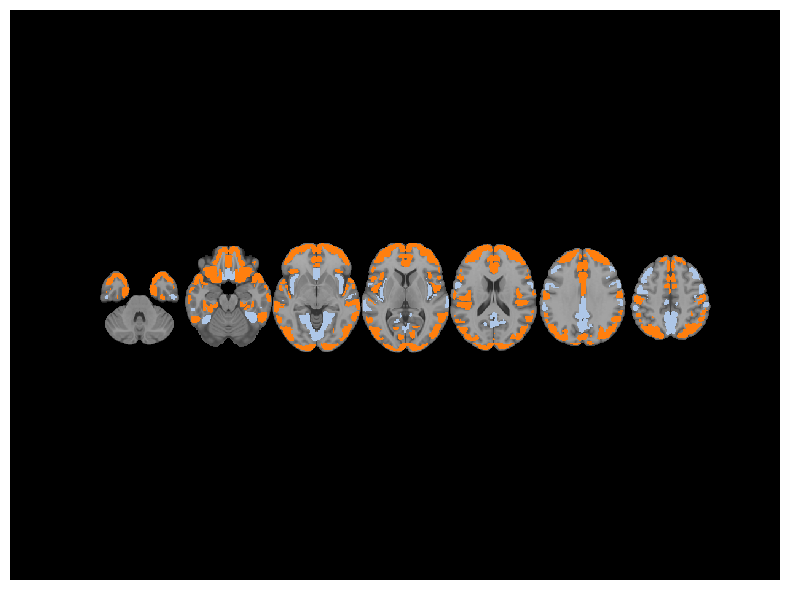

  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_100_max(λ).pdf


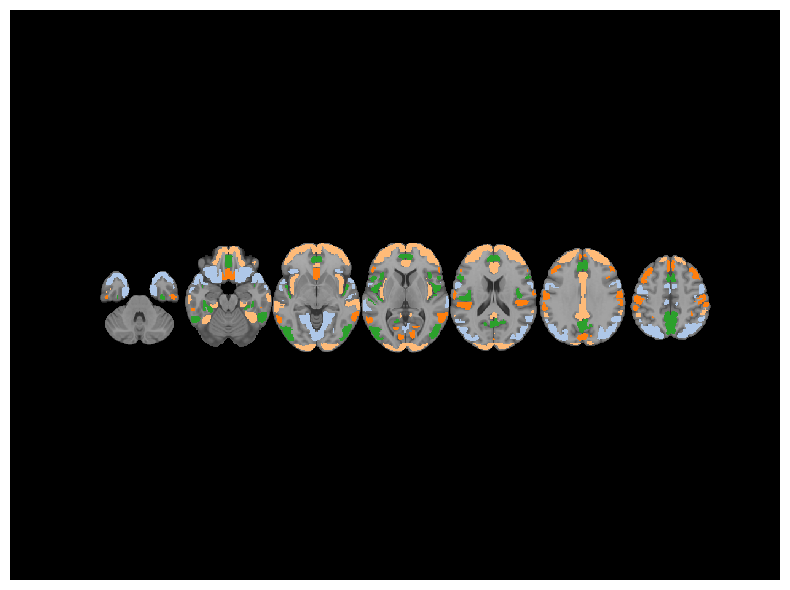

  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_10_max(λ).pdf


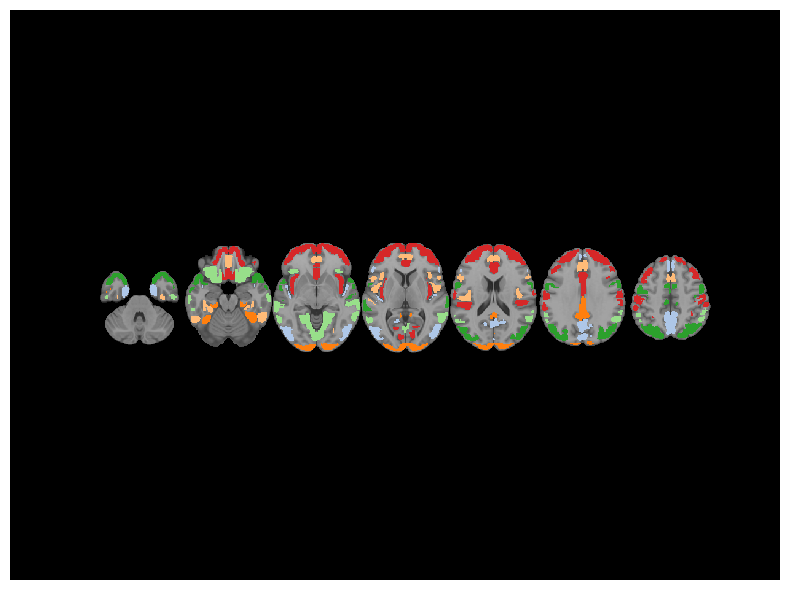

  Saved: brain_partition_S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_1_max(λ).pdf

Processing visualizations for matrix: S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold


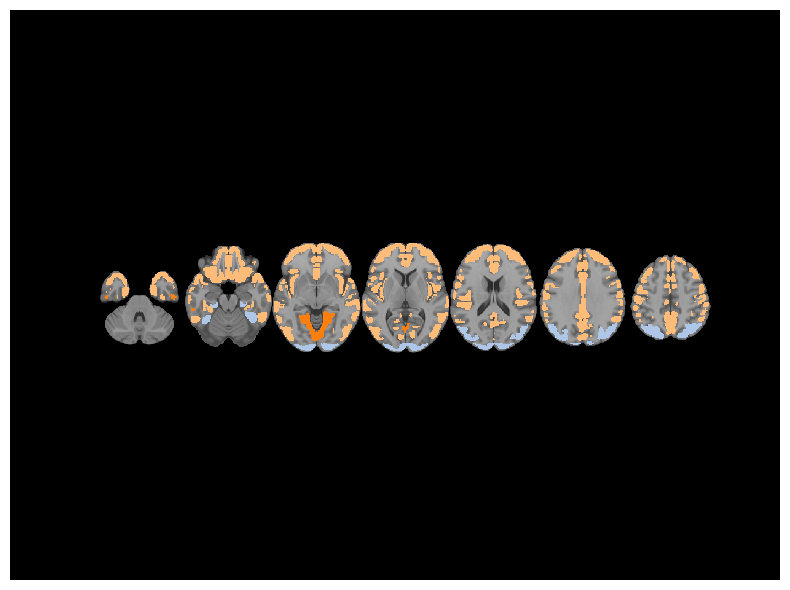

  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_100_max(λ).pdf


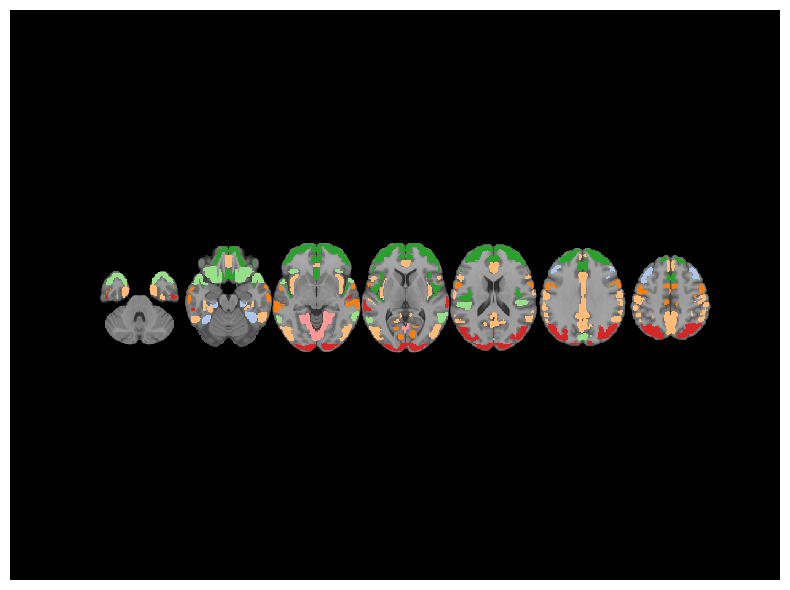

  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_10_max(λ).pdf


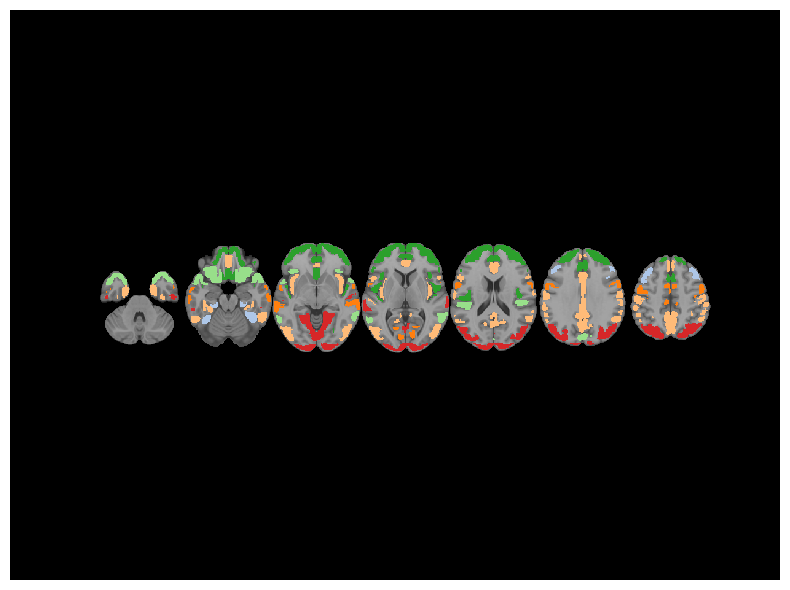

  Saved: brain_partition_S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold_tau_1_max(λ).pdf

Processing visualizations for matrix: S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold


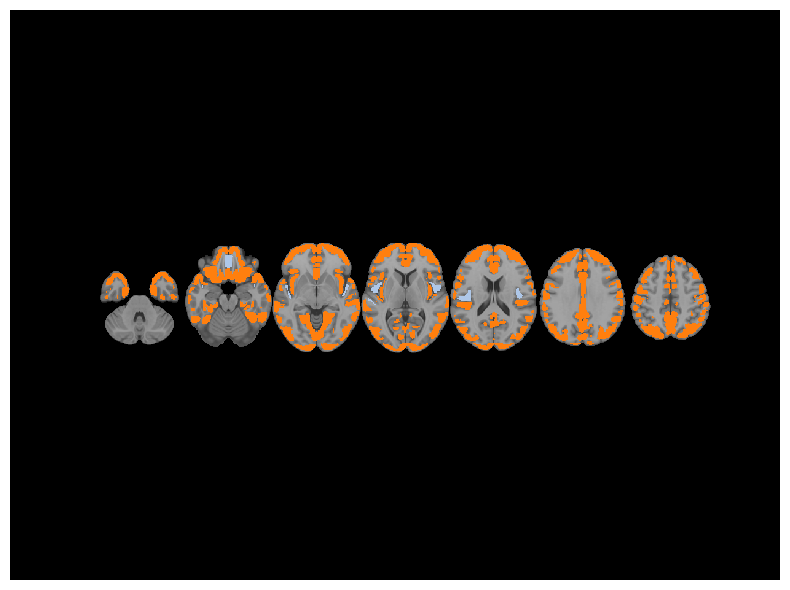

  Saved: brain_partition_S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_100_max(λ).pdf


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x74ac046b5010>>
Traceback (most recent call last):
  File "/home/opisthofulax/anaconda3/envs/multifun-brain/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


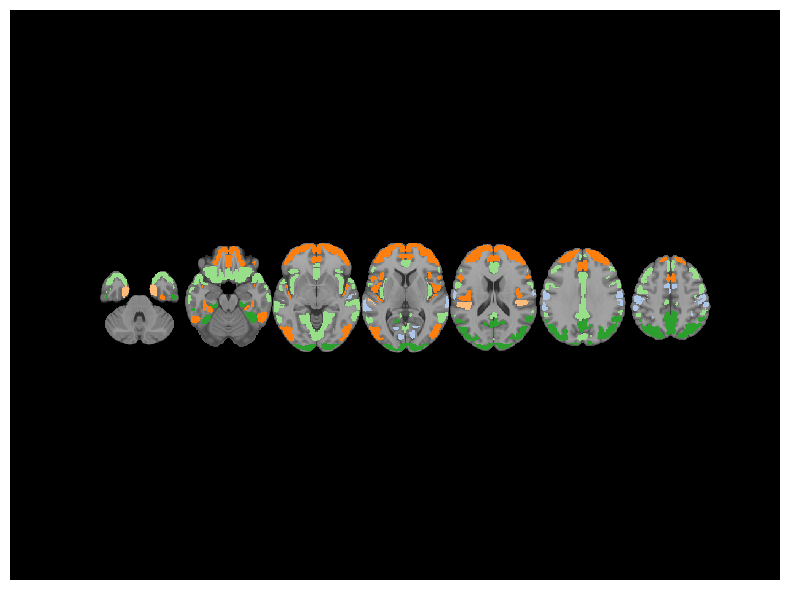

  Saved: brain_partition_S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_10_max(λ).pdf


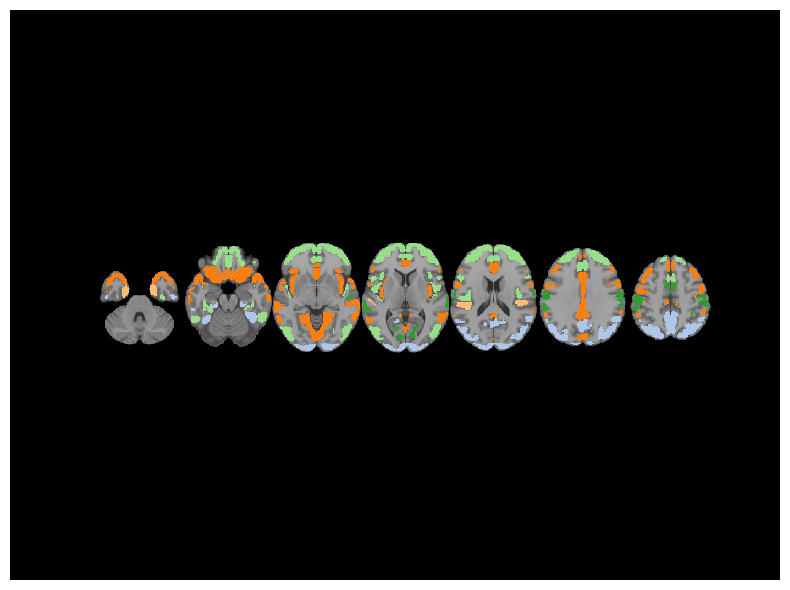

  Saved: brain_partition_S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold_tau_1_max(λ).pdf

Processing visualizations for matrix: S5S4Special_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold


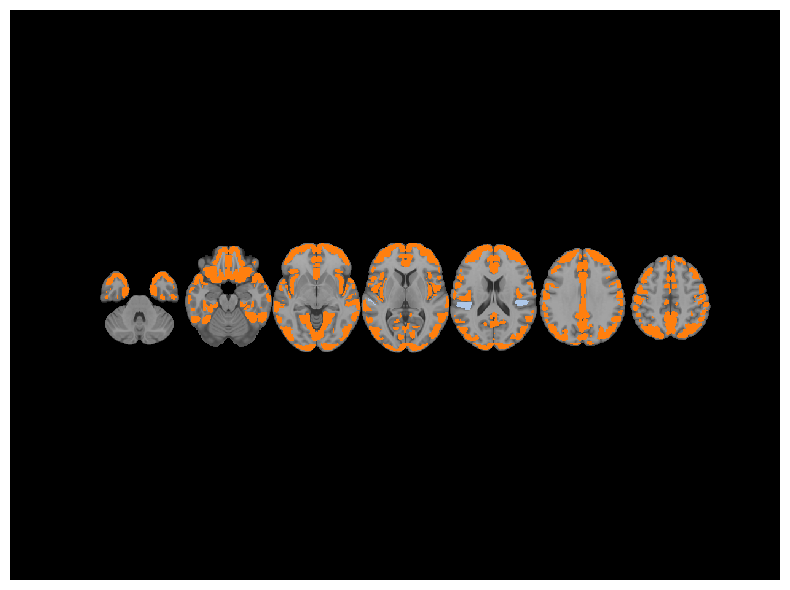

In [ ]:
# Create separate visualizations for each matrix and tau combination
# Only use matrices that were successfully processed
processed_fnames = [fn for fn in fnames if fn in all_results]
print(f"Creating individual visualizations for {len(processed_fnames)} successfully processed matrices out of {len(fnames)} total")

# Generate a color palette for clusters
colors = plt.cm.tab20(np.linspace(0, 1, 20))  # Up to 20 different colors

# Store all created figures for potential batch operations
all_figures = []

for matrix_idx, fn in enumerate(processed_fnames):
    # Get clean matrix name for display
    matrix_name = fn.replace('HarvardOxford_48Parcels_', '').replace('.ts.1D.pkl', '')
    print(f"\nProcessing visualizations for matrix: {matrix_name}")
    
    for tau_idx, multiplier in enumerate(tau_multipliers):
        # Create individual figure for each brain map
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        
        # Get clustering results
        cluster_result = all_results[fn]['clusters'][multiplier]
        optimal_clusters = cluster_result['optimal_clusters']
        lost_nodes = all_results[fn]['lost_nodes']
        n_clusters = cluster_result['n_clusters']
        tau_value = cluster_result['tau']
        
        # Create node colors based on cluster assignments
        node_colors = [colors[cluster_id % len(colors)] for cluster_id in optimal_clusters]
        
        # Insert white color for lost nodes (nodes not in giant component)
        indices_to_insert = sorted(lost_nodes)
        node_colors_all = node_colors.copy()
        for idx in reversed(indices_to_insert):
            node_colors_all.insert(idx, 'white')
        
        # Create colormap
        cmap = ListedColormap(node_colors_all)
        
        # Plot brain map
        plotting.plot_stat_map(
            atlas_img, 
            bg_img=template, 
            axes=ax, 
            cmap=cmap,
            colorbar=False,
        )
        
        # Set comprehensive title
        
        plt.tight_layout()
        plt.show()
        
        # Save individual figure
        safe_matrix_name = matrix_name.replace('/', '_').replace(' ', '_')
        safe_tau_name = tau_names[tau_idx].replace('/', '_').replace(' ', '_')
        filename = f'brain_partition_{safe_matrix_name}_tau_{safe_tau_name}.pdf'
        fig.savefig(path_fig / filename, bbox_inches='tight', transparent=True, dpi=300)
        print(f"  Saved: {filename}")
        
        # Store figure reference
        all_figures.append({
            'figure': fig,
            'matrix': matrix_name,
            'tau': tau_names[tau_idx],
            'filename': filename
        })

print(f"\nCompleted visualization creation. Generated {len(all_figures)} individual brain maps.")
print(f"All figures saved to: {path_fig}")

In [ ]:
# Create summary table of clustering results
import pandas as pd

# Prepare data for summary table (only for successfully processed matrices)
summary_data = []

for fn in all_results.keys():
    matrix_name = fn.replace('HarvardOxford_48Parcels_', '').replace('.ts.1D.pkl', '')
    
    for multiplier in tau_multipliers:
        cluster_result = all_results[fn]['clusters'][multiplier]
        
        summary_data.append({
            'Matrix': matrix_name,
            'Tau_Multiplier': f'{multiplier}/max(λ)',
            'Tau_Value': f"{cluster_result['tau']:.6f}",
            'N_Clusters': cluster_result['n_clusters'],
            'Threshold': f"{cluster_result['threshold']:.4f}",
            'Max_Eigenvalue': f"{all_results[fn]['max_eigenvalue']:.4f}",
            'Lost_Nodes': len(all_results[fn]['lost_nodes'])
        })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the summary table
print("="*80)
print("MULTISCALE ANALYSIS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Create a pivot table for better visualization
pivot_clusters = summary_df.pivot(index='Matrix', columns='Tau_Multiplier', values='N_Clusters')
print("\nNumber of Clusters by Matrix and Time Scale:")
print("-"*50)
print(pivot_clusters.to_string())

# Save summary to file
summary_df.to_csv(path_data / 'multiscale_analysis_summary.csv', index=False)
print(f"\nSummary table saved to: {path_data / 'multiscale_analysis_summary.csv'}")

# Calculate and display some statistics
print(f"\nStatistics:")
print(f"- Total matrices analyzed: {len(fnames)}")
print(f"- Time scales per matrix: {len(tau_multipliers)}")
print(f"- Average number of clusters across all conditions: {summary_df['N_Clusters'].mean():.1f}")
print(f"- Range of clusters found: {summary_df['N_Clusters'].min()} - {summary_df['N_Clusters'].max()}")
print(f"- Most common number of clusters: {summary_df['N_Clusters'].mode().iloc[0]}")

# Show how clustering changes with tau
print(f"\nClustering trends by time scale:")
for multiplier in tau_multipliers:
    subset = summary_df[summary_df['Tau_Multiplier'] == f'{multiplier}/max(λ)']
    mean_clusters = subset['N_Clusters'].mean()
    print(f"- τ = {multiplier}/max(λ): {mean_clusters:.1f} clusters on average")

MULTISCALE ANALYSIS SUMMARY
                                                   Matrix Tau_Multiplier Tau_Value  N_Clusters Threshold Max_Eigenvalue  Lost_Nodes
         S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold     100/max(λ)  6.947119           2    0.9901        14.3945           0
         S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold      10/max(λ)  0.694712           2    0.9581        14.3945           0
         S5_corrfrom_imf_cumul_3_kwoptcomMIRDenoised_bold       1/max(λ)  0.069471           4    0.6315        14.3945           0
             S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold     100/max(λ)  4.358098           3    0.9901        22.9458           0
             S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold      10/max(λ)  0.435810           2    0.8905        22.9458           0
             S5S4Special_corrfrom_imf_cumul_2_kwfurN_Bold       1/max(λ)  0.043581           7    0.1970        22.9458           0
       S5S4_corrfrom_imf_cumul_3_kwoptcomMIRDeno